2017: GOS2017114.npy, station 300, oxygen unit = raw_as_mL/L
2018: GOS2018111.npy, station 415, oxygen unit = raw_as_mL/L
2019: GOS2019114.npy, station 385, oxygen unit = umol/kg_to_mL/L

================ Mean values for each year ================

 year  sigma0_110_270  sigma0_270_bottom  sigma0_110_325  sigma0_325_bottom  CT_110_325  CT_325_bottom  SA_110_270  SA_270_bottom  SA_325_bottom  DO_110_325  DO_325_bottom  DO_110_450
 2017         27.1816            27.2800         27.2026            27.2861      8.2308         8.1354     35.0974        35.1994        35.2069      2.9752         1.5019      2.4402
 2018         27.2186            27.2531         27.2236            27.2589      8.0860         8.1332     35.1119        35.1608        35.1716      3.9326         1.7904      3.1691
 2019         27.1969            27.2418         27.2052            27.2463      8.1799         8.1068     35.1054        35.1450        35.1503      3.8541         2.4073      3.3372

==============

C:\Users\quzho2904\AppData\Local\Temp\ipykernel_25384\2101803925.py:191: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2017-2018' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_change.loc[i, "year_pair"] = f"{df_mean.loc[i-1, 'year']}-{df_mean.loc[i, 'year']}"


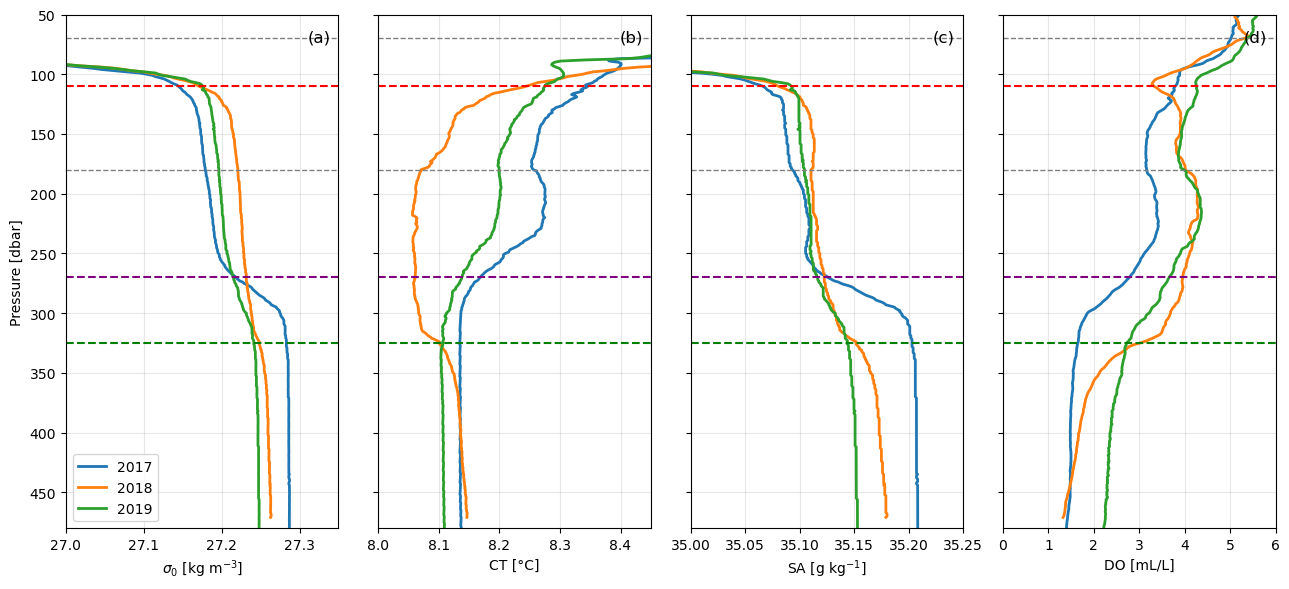

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import gsw

# =========================
# 1. File paths and station settings
# =========================
data_dir = Path(r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\npy")
fig_dir = Path(r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\figures")
fig_dir.mkdir(parents=True, exist_ok=True)

files = {
    "2017": ("GOS2017114.npy", 300),
    "2018": ("GOS2018111.npy", 415),
    "2019": ("GOS2019114.npy", 385),
}

# sill depths
sill_depths = [70, 180]

# analysis layer lines
layer_lines = {
    110: "red",
    270: "purple",
    325: "green"
}

# =========================
# 2. Read one station profile and compute variables
# =========================
def load_station_profile(file_path, station_id):
    """
    Read one CTD profile from a .npy file and compute:
    P, sigma0, CT, SA, DO_mLL
    """

    D = np.load(file_path, allow_pickle=True).item()

    if station_id not in D:
        raise KeyError(
            f"Station {station_id} not found in {file_path.name}.\n"
            f"Available stations: {list(D.keys())}"
        )

    prof = D[station_id]

    P  = np.asarray(prof["P"], dtype=float)
    T  = np.asarray(prof["T"], dtype=float)   # in-situ temperature
    SP = np.asarray(prof["S"], dtype=float)   # practical salinity
    OX = np.asarray(prof["OX"], dtype=float)

    lon = float(prof["LON"])
    lat = float(prof["LAT"])

    # basic quality control
    good = np.isfinite(P) & np.isfinite(T) & np.isfinite(SP) & np.isfinite(OX)

    P  = P[good]
    T  = T[good]
    SP = SP[good]
    OX = OX[good]

    # sort by pressure (shallow -> deep)
    idx = np.argsort(P)
    P  = P[idx]
    T  = T[idx]
    SP = SP[idx]
    OX = OX[idx]

    # TEOS-10 calculations
    SA = gsw.SA_from_SP(SP, P, lon, lat)
    CT = gsw.CT_from_t(SA, T, P)
    sigma0 = gsw.sigma0(SA, CT)

    rho = gsw.rho(SA, CT, P)      # kg/m3
    rho_kgL = rho / 1000.0        # kg/L

    # convert oxygen to mL/L
    O_mean_raw = np.nanmean(OX)

    if O_mean_raw < 20:
        DO_mLL = OX
        unit_flag = "raw_as_mL/L"
    else:
        DO_mLL = OX * rho_kgL / 44.66
        unit_flag = "umol/kg_to_mL/L"

    return {
        "P": P,
        "sigma0": sigma0,
        "CT": CT,
        "SA": SA,
        "DO_mLL": DO_mLL,
        "unit_flag": unit_flag,
    }


# =========================
# 3. Helper function for layer mean
# =========================
def layer_mean(P, X, pmin, pmax=None):
    """
    Compute simple mean of X within a pressure layer.

    If pmax is None, compute mean from pmin to bottom.
    Assumes profile is already on a sufficiently fine grid
    (here effectively 1 dbar spacing).
    """
    P = np.asarray(P, dtype=float)
    X = np.asarray(X, dtype=float)

    good = np.isfinite(P) & np.isfinite(X)
    P = P[good]
    X = X[good]

    if pmax is None:
        mask = P >= pmin
    else:
        mask = (P >= pmin) & (P <= pmax)

    if np.sum(mask) == 0:
        return np.nan

    return np.nanmean(X[mask])


# =========================
# 4. Read all profiles
# =========================
profiles = {}

for label, (fname, st) in files.items():
    file_path = data_dir / fname
    profiles[label] = load_station_profile(file_path, st)
    print(f"{label}: {fname}, station {st}, oxygen unit = {profiles[label]['unit_flag']}")


# =========================
# 5. Compute layer-mean values
# =========================
results = []

for year in sorted(profiles.keys()):
    prof = profiles[year]
    P = prof["P"]

    row = {
        "year": int(year),

        # sigma0
        "sigma0_110_270": layer_mean(P, prof["sigma0"], 110, 270),
        "sigma0_270_bottom": layer_mean(P, prof["sigma0"], 270, None),
        # additional sigma0 layer for renewal signal
        "sigma0_110_325": layer_mean(P, prof["sigma0"], 110, 325),
        "sigma0_325_bottom": layer_mean(P, prof["sigma0"], 325, None),

        # CT
        "CT_110_325": layer_mean(P, prof["CT"], 110, 325),
        "CT_325_bottom": layer_mean(P, prof["CT"], 325, None),

        # SA
        "SA_110_270": layer_mean(P, prof["SA"], 110, 270),
        "SA_270_bottom": layer_mean(P, prof["SA"], 270, None),
        "SA_325_bottom": layer_mean(P, prof["SA"], 325, None),

        # DO
        "DO_110_325": layer_mean(P, prof["DO_mLL"], 110, 325),
        "DO_325_bottom": layer_mean(P, prof["DO_mLL"], 325, None),

        # additional oxygen layer for renewal signal
        "DO_110_450": layer_mean(P, prof["DO_mLL"], 110, 450),
    }

    results.append(row)

df_mean = pd.DataFrame(results).sort_values("year").reset_index(drop=True)


# =========================
# 6. Compute year-to-year changes
# =========================
df_change = df_mean.copy()

value_cols = [col for col in df_mean.columns if col != "year"]
df_change[value_cols] = df_mean[value_cols].diff()

df_change["year_pair"] = np.nan
for i in range(1, len(df_change)):
    df_change.loc[i, "year_pair"] = f"{df_mean.loc[i-1, 'year']}-{df_mean.loc[i, 'year']}"


# =========================
# 7. Print results
# =========================
pd.set_option("display.precision", 4)

print("\n================ Mean values for each year ================\n")
print(df_mean.to_string(index=False))

print("\n================ Year-to-year changes ================\n")
print(df_change.loc[1:, ["year_pair"] + value_cols].to_string(index=False))


# =========================
# 8. Print readable summary
# =========================
print("\n================ Readable summary ================\n")

for i in range(1, len(df_mean)):
    y0 = int(df_mean.loc[i - 1, "year"])
    y1 = int(df_mean.loc[i, "year"])

    print(f"From {y0} to {y1}:")
    print(f"  sigma0 110-270 dbar   : {df_mean.loc[i, 'sigma0_110_270']:.4f} "
          f"({df_mean.loc[i, 'sigma0_110_270'] - df_mean.loc[i-1, 'sigma0_110_270']:+.4f})")
    print(f"  sigma0 270-bottom     : {df_mean.loc[i, 'sigma0_270_bottom']:.4f} "
          f"({df_mean.loc[i, 'sigma0_270_bottom'] - df_mean.loc[i-1, 'sigma0_270_bottom']:+.4f})")

    print(f"  CT 110-325 dbar       : {df_mean.loc[i, 'CT_110_325']:.4f} "
          f"({df_mean.loc[i, 'CT_110_325'] - df_mean.loc[i-1, 'CT_110_325']:+.4f})")
    print(f"  CT 325-bottom         : {df_mean.loc[i, 'CT_325_bottom']:.4f} "
          f"({df_mean.loc[i, 'CT_325_bottom'] - df_mean.loc[i-1, 'CT_325_bottom']:+.4f})")

    print(f"  SA 110-270 dbar       : {df_mean.loc[i, 'SA_110_270']:.4f} "
          f"({df_mean.loc[i, 'SA_110_270'] - df_mean.loc[i-1, 'SA_110_270']:+.4f})")
    print(f"  SA 270-bottom         : {df_mean.loc[i, 'SA_270_bottom']:.4f} "
          f"({df_mean.loc[i, 'SA_270_bottom'] - df_mean.loc[i-1, 'SA_270_bottom']:+.4f})")

    print(f"  DO 110-325 dbar       : {df_mean.loc[i, 'DO_110_325']:.4f} "
          f"({df_mean.loc[i, 'DO_110_325'] - df_mean.loc[i-1, 'DO_110_325']:+.4f})")
    print(f"  DO 325-bottom         : {df_mean.loc[i, 'DO_325_bottom']:.4f} "
          f"({df_mean.loc[i, 'DO_325_bottom'] - df_mean.loc[i-1, 'DO_325_bottom']:+.4f})")
    print("")


# =========================
# 9. Save tables
# =========================
df_mean.to_csv(fig_dir / "Masfjorden_layer_means_2017_2019.csv", index=False)
df_change.to_csv(fig_dir / "Masfjorden_layer_changes_2017_2019.csv", index=False)


# =========================
# 10. Plot 4-panel figure
# =========================
fig, axes = plt.subplots(1, 4, figsize=(13, 6), sharey=True)

panel_info = [
    ("sigma0", r"$\sigma_0$ [kg m$^{-3}$]", (27.0, 27.35)),
    ("CT", "CT [°C]", (8.0, 8.45)),
    ("SA", r"SA [g kg$^{-1}$]", (35.0, 35.25)),
    ("DO_mLL", "DO [mL/L]", (0.0, 6.0))
]

for ax, (var, xlabel, xlim) in zip(axes, panel_info):

    for label, prof in profiles.items():
        ax.plot(
            prof[var],
            prof["P"],
            linewidth=2,
            label=label
        )

    # sill depth lines
    for sd in sill_depths:
        ax.axhline(
            sd,
            linestyle="--",
            linewidth=1,
            color="gray"
        )

    # analysis layer lines
    for depth, color in layer_lines.items():
        ax.axhline(
            depth,
            linestyle="--",
            linewidth=1.5,
            color=color
        )

    ax.set_xlabel(xlabel)
    ax.set_xlim(xlim)
    ax.grid(alpha=0.3)
    ax.invert_yaxis()

# shared y-axis range
axes[0].set_ylim(480, 50)
axes[0].set_ylabel("Pressure [dbar]")

# legend only on first subplot
axes[0].legend(loc="lower left")

# subplot labels
for ax, letter in zip(axes, ["(a)", "(b)", "(c)", "(d)"]):
    ax.text(
        0.97,
        0.97,
        letter,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=12
    )

plt.tight_layout()

# save figure
fig_name = "Masfjorden_profiles_2017_2019_layers"

plt.savefig(
    fig_dir / f"{fig_name}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    fig_dir / f"{fig_name}.pdf",
    bbox_inches="tight"
)

plt.show()